# 2d Ornstein-Uhlenbeck example

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'

import sys
sys.path.insert(0, os.path.abspath('..'))

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
import optax

import flax
import flax.linen as nn

from src.consistency_bridge import ConsistencyBridge

from src.models import ScoreMLP, ConservativeMLP
from src.plotting import plot_multiple_trajectories, plot_trajectories_with_background

## define base drift

In [2]:
a = 0.0
b = 2.0

def base_drift(x, t):
    # drift of the base process: Ornstein-Uhlenbeck process
    return a - b * x

## Train Consistency Bridge

In [ ]:
sigma = 0.1
d = 2

shape = (d,)

x_0 = jnp.array([1.0, 0.0])
x_T = jnp.array([0.0, 1.0])

T = 1.0

# model = ScoreMLP(
#     dim_hidden=(256, 256, 256), #(128, 128),
#     emb_dim_hidden=(128, 128), #(64, 64),
#     activation=nn.gelu,
#     out_dim=d
# )

model = ConservativeMLP(
    dim_hidden=(128, 128),
    emb_dim_hidden=(64, 64),
    activation=nn.gelu,
)

bridge_config = {
        'base_drift': False, 
        'guiding_type': 'brownian',
        'decay_coeff': False,
        'sampler': 'euler',
    }

bridge = ConsistencyBridge(
    shape=shape,
    x_0=x_0,
    x_T=x_T,
    base_drift_fn=base_drift,
    sigma_fn=sigma,
    model=model,
    bridge_config=bridge_config,
    T=T
)

Training: 100%|████████████████████████| 2000/2000 [00:36<00:00, 54.82step/s, loss=8.9704e+02, ema_grad_norm=1.3090e+03]


Training finished.


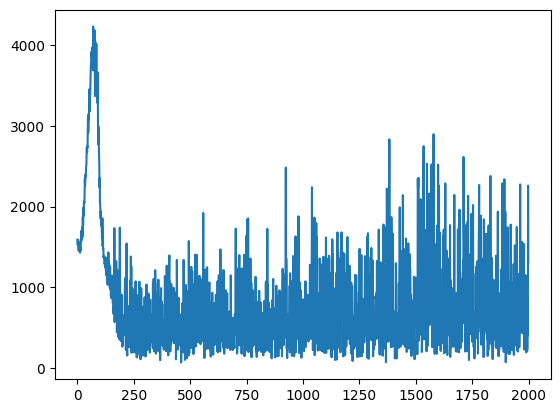

In [4]:
train_config = {
    'self_consistency': 'standard', # standard, nodrift,
    'num_steps': 100, #500,                # number of discretisation steps
    'num_outer_iterations': 2_000, #5_000, 
    'num_inner_iterations': 1,      # number of inner iterations
    'traj_batch_size': 64,          # number of trajectories per outer iteration
    'train_batch_size': 20_000, #4096,       # number of training samples per inner iteration
    'lr': 1e-4,                 # learning rate
    'ema_rate': 1.0, # ema rate: 1.0 means no ema
    'jacobian_method': 'euler', 
    'beta_schedule': 'average', # 'average', 'beta', 'endpoint', 'next_step',
    'B_ratio': 0.9,
    'ckpt_freq': 100,          # frequency of checkpoints
}

key = jax.random.PRNGKey(0)
state, ema_params_lst, ema_grad_norms = bridge.train(key, train_config)

plt.plot(ema_grad_norms)

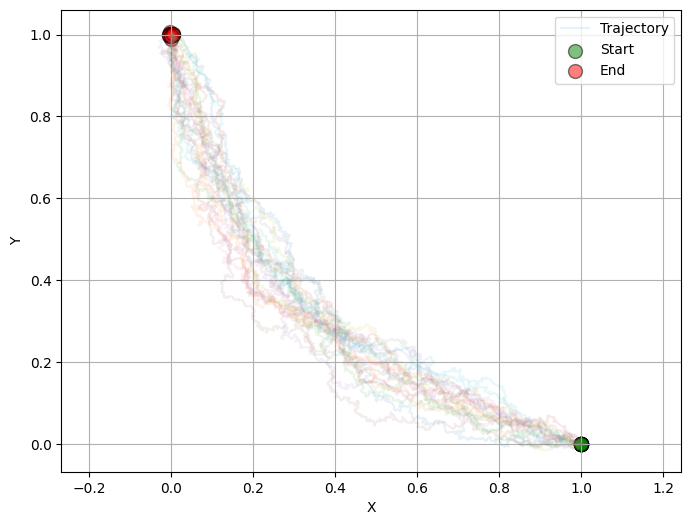

In [5]:
num_trajs = 64
num_steps = 1000
sample_keys = jax.random.split(key, num_trajs)

idx = -1 
ema_params = ema_params_lst[idx]  # use the last ema parameters

ts = jnp.linspace(0, T, num_steps + 1)
x_traj, drift_traj, dB_t_traj = jax.vmap(
        bridge.sample_controlled_sde,
        in_axes=(0, None, None)
        )(sample_keys, ema_params, num_steps) # (B,N+1,d), (B,N,d), (B,N,d)

plot_multiple_trajectories(x_traj[:20], alpha=0.5)

## Compare to ground truth

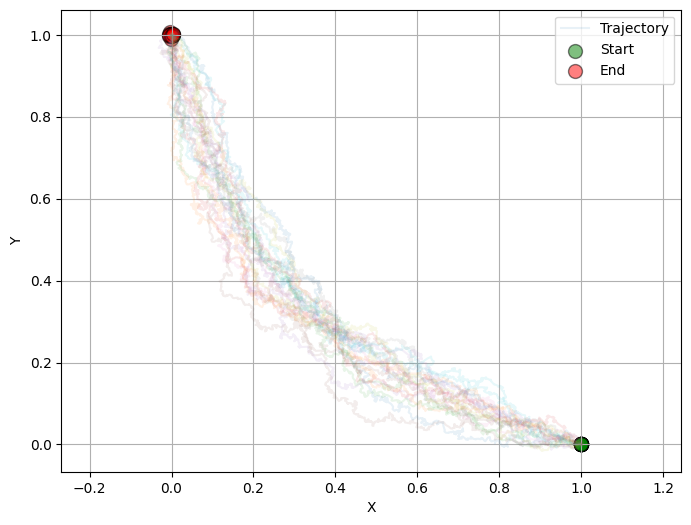

In [6]:
def OU_mean(x, s):
    return (a / b) + (x - (a / b)) * jnp.exp(-b * s)

def OU_var(s):
    return (1 - jnp.exp(-2 * b * s)) / (2 * b) * sigma**2

def true_h_transform(x, t):
    return ( jnp.exp(-b * (T-t)) / OU_var(T-t) ) * (x_T - OU_mean(x, T-t))

def true_OU_bridge_drift(x,t):
    # drift of the Ornstein-Uhlenbeck bridge
    return base_drift(x, t) + sigma**2 * true_h_transform(x, t)

num_trajs = 64
num_steps = 1000
sample_keys = jax.random.split(key, num_trajs)

idx = -1 #600
x_traj, drift_traj, dBt_traj = jax.vmap(
        bridge.sample_sde,
        in_axes=(0, None, None)
        )(sample_keys, true_OU_bridge_drift, num_steps) # (B,N+1,d), (B,N,d), (B,N,d)

plot_multiple_trajectories(x_traj[:20], alpha=0.5)